# Final results: reconstruction and reusable representations

The comparison uses **5,935 previously reserved events**. Models, calibrations, noise seeds and reporting rules were frozen before evaluation. Nothing was retrained or selected on test. This notebook reads verified aggregate reports; it does not load raw data or execute training.

The strongest result is a useful **position representation**. Energy remains more mixed. [Methods and decisions](02_methods_and_decisions.ipynb) explains the route from the initial experiments to this selected methodology.


In [1]:
import json
from pathlib import Path

from IPython.display import Image, Markdown, display

project = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "configs/final_evaluation.json").exists()
)
report = json.loads((project / "reports/final/results.json").read_text())
assert report["complete"] and report["test_used"]
assert report["verification"]["all_91_prediction_files_checked"]
labels = {"cnn": "CNN", "transformer": "Direct Transformer", "finetuning": "Pretrained Transformer"}
rows = ["| Method | Energy MARE (%) | Median position error |", "| --- | ---: | ---: |"]
for row in report["main_accuracy"]:
    label = labels[row["family"]]
    energy = 100 * row["energy"]["mean"]
    position = row["position"]["mean"]
    rows.append(f"| {label} | {energy:.3f} | {position:.5f} |")
display(Markdown("\n".join(rows)))

| Method | Energy MARE (%) | Median position error |
| --- | ---: | ---: |
| CNN | 4.188 | 0.10577 |
| Direct Transformer | 2.554 | 0.07040 |
| Pretrained Transformer | 2.389 | 0.04643 |

## 1. Does the result survive on new events?

Neural values are **means of three scores**, not an ensemble. Energy MARE is mean absolute fractional error. Position uses stored coordinate units, not centimeters.

Pretraining improves position on all three paired seeds and beats the periodic reference. For energy, one seed improves clearly; the other two have slightly worse point estimates with event-bootstrap intervals spanning no difference. The quadratic reference remains better on average.

Open diamonds recall validation means; filled dots are individual test runs. The weights are unchanged. The two samples have independent readout noise.


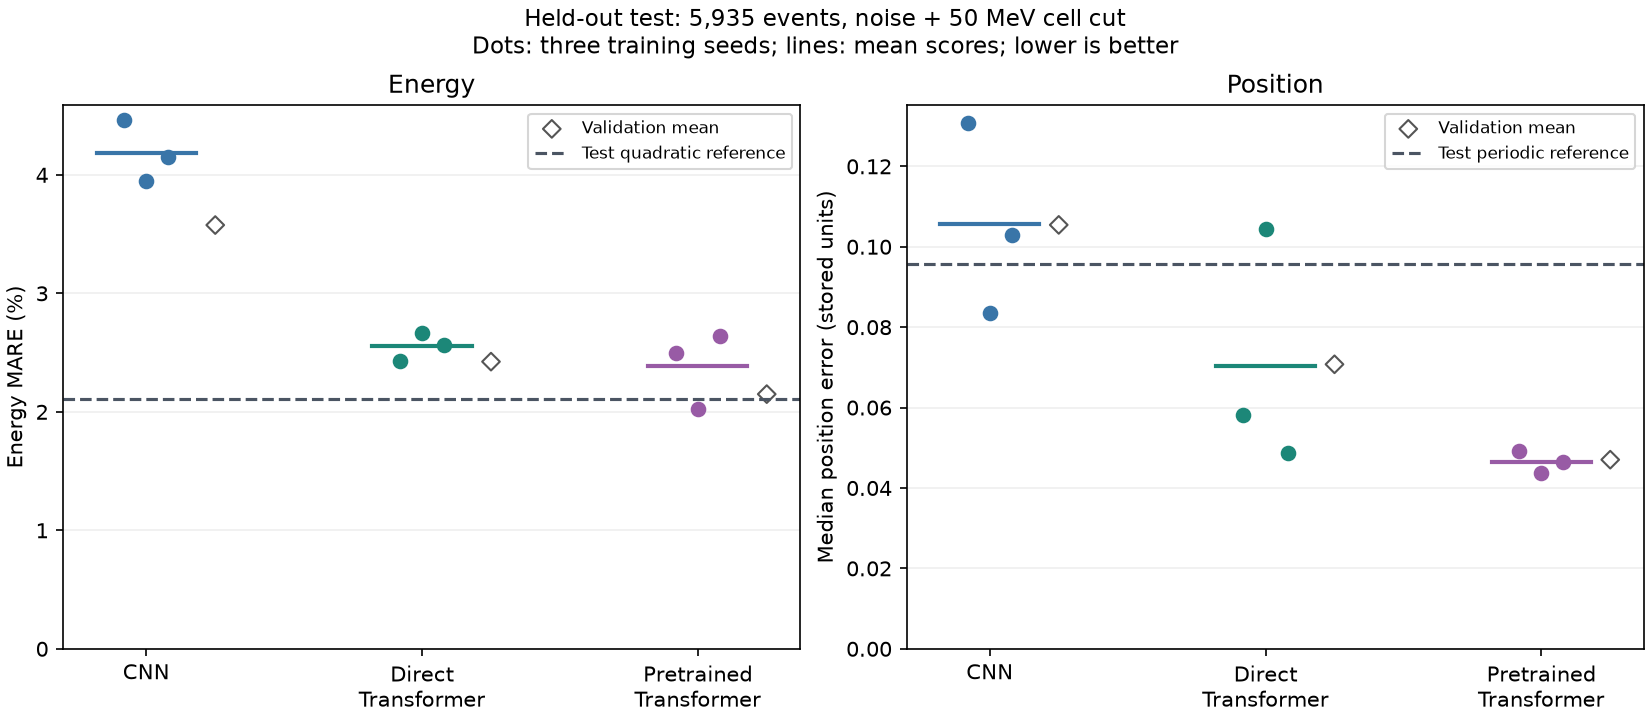

In [2]:
display(Image(filename=str(project / "reports/final/accuracy.png")))

## 2. What remains physically difficult?

The 7 x 7 window is centered on the largest **measured** crystal. For a weak shower, a noise fluctuation can move it far from the real signal. Seven of 5,935 primary test events have gross position errors, all around 1 GeV. They remain in the scores.

The ordinary tail (99th percentile) improves, but rare mistakes dominate RMSE. Some energy predictions are nonpositive too; no clipping hides them.

Clean and noise-only controls remain in the report. Noise worsens absolute reconstruction but changes the usefulness of learned spatial information. The position advantage appears with noise alone: the 50 MeV cell cut is not necessary to observe it. This simplified readout is not full detector digitization.


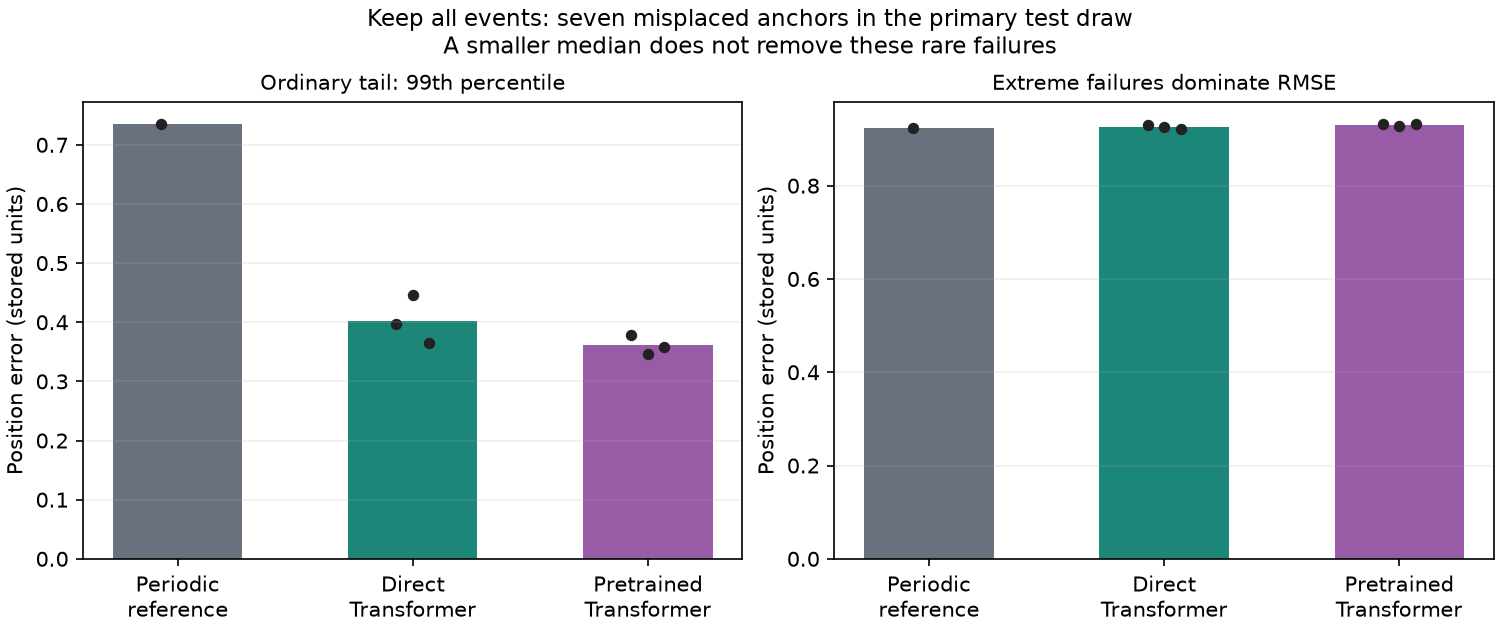

In [3]:
display(Image(filename=str(project / "reports/final/tails.png")))

## 3. What does the pretrained encoder cost to reuse?

With an encoder already available, position fine-tuning reaches the direct model's validation target in **2.03 active minutes versus 4.01** on average. Initial pretraining costs **7.21 minutes** separately.

These are retrospective target crossings, not an executed early-stopping policy. All models completed 4,400 updates, and full fine-tuning schedules took approximately as long as direct schedules. Full-budget accuracy and target-crossing time refer to different checkpoints.

The two studied tasks do not amortize pretraining. Reuse on further tasks could help only if acceptable quality and adaptation-time savings persist. The conditional calculation and per-seed timings are consolidated in the [final report](../reports/final/README.md#adaptation-time-and-reuse).


## Scope of the conclusion

This is a reusable local representation for two tasks on one simulated detector. The strongest benefit is position under the assumed noisy readout. It does not establish a universal foundation model, new-task success or real-detector transfer. Three seeds share one training sample and noise draw. Event-bootstrap intervals condition on fixed models; they do not measure general training variability.

Read the [final report](../reports/final/README.md) for individual seeds, controls and uncertainty. Optional execution and verification details are in [Reproduce the study](../docs/reproduce.md).
